## Baseline and compressed school

This experiment asks whether centroid contraction increases cascade propagation
with the calibrated threshold and response coefficients held fixed.
We compare the baseline school with the same school at `spatial_scale = 0.7`.

Every paired trial uses the same fish-specific thresholds, starter, and dose
random seed. These draws vary between trials. Both networks use the same
`network_seed` and sampling parameters, which reproduce identical initial
positions and headings before scaling. The school itself stays fixed across
trials.

The dose accumulation, threshold rule, and state transitions are implemented in
[cascade.py](cascade.py), using the loop from [simulation.ipynb](simulation.ipynb).
The threshold calibration is in [baseline_calibration.ipynb](baseline_calibration.ipynb).


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from network import synthetic_spatial_network
from cascade import cascade_size

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)


In [2]:
n_fish = 40
mean_threshold = 0.005596
dt = 0.001
active_duration = 0.5
memory_duration = 2.0
dose_rate = 1000.0
dose_size = 0.001


In [3]:
intercept = 0.06449
distance_coefficient = -3.20552
rank_coefficient = -0.08016


In [4]:
arena_size_cm = (66.6, 66.6)
min_separation_cm = 3.0
body_width_cm = 2.0
field_of_view_deg = 360.0
max_visual_distance_cm = None
occlusion = True
network_seed = 2026


In [5]:
spatial_scales = np.array([1.0, 0.7])
condition_labels = ["Baseline", "Compressed"]
condition_colors = ["tab:blue", "tab:red"]
n_runs = 1000
run_ids = np.arange(n_runs)


In [6]:
adjacency_matrices = []
geometries = []
for spatial_scale in spatial_scales:
    adjacency, geometry = synthetic_spatial_network(
        n_fish, intercept, distance_coefficient, rank_coefficient,
        arena_size_cm=arena_size_cm, min_separation_cm=min_separation_cm,
        body_width_cm=body_width_cm, field_of_view_deg=field_of_view_deg,
        max_visual_distance_cm=max_visual_distance_cm, occlusion=occlusion,
        spatial_scale=spatial_scale, random_seed=network_seed, return_geometry=True,
    )
    adjacency_matrices.append(adjacency)
    geometries.append(geometry)


Contraction changes pairwise distance, apparent angular size, and occlusion.
The diagnostics show both the number of visible neighbours and the strength of
non-zero interactions. Minimum distance describes the closest pair after scaling;
`min_separation_cm` is enforced during initial placement.

Black crosses in the spatial plots mark the unchanged centroid.


In [7]:
print("Condition   Median NND  Min distance  Visible mean  Weight mean  Weight P90")
for label, adjacency, geometry in zip(condition_labels, adjacency_matrices, geometries):
    nearest_neighbour_cm = geometry["distance_cm"].min(axis=1)
    weights = adjacency[adjacency > 0]
    print(f"{label:<11} {np.median(nearest_neighbour_cm):9.3f} "
          f"{nearest_neighbour_cm.min():13.3f} {geometry['visible'].sum(axis=1).mean():13.3f} "
          f"{weights.mean():12.5f} {np.quantile(weights, 0.9):11.5f}")


Condition   Median NND  Min distance  Visible mean  Weight mean  Weight P90
Baseline        6.001         3.058        23.975      0.01150     0.02773
Compressed      4.201         2.140        19.900      0.02133     0.05256


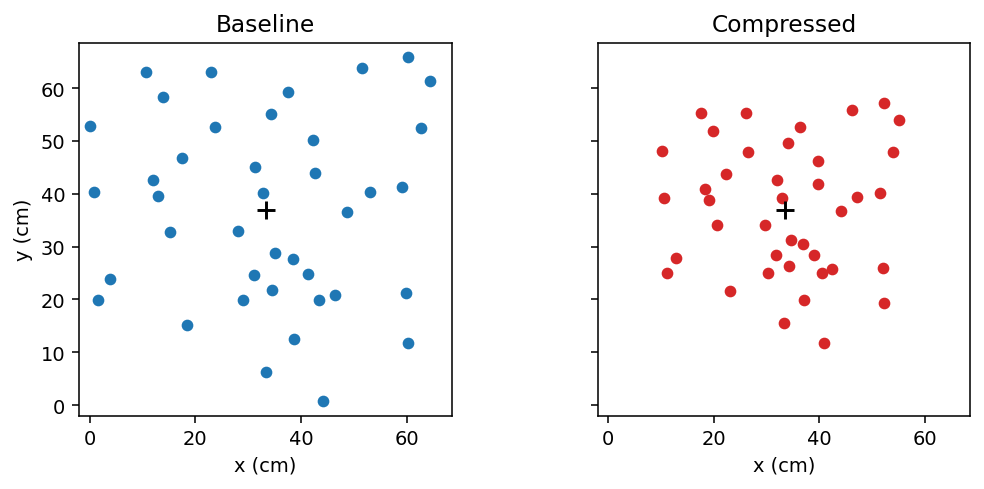

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), sharex=True, sharey=True)
for ax, label, color, geometry in zip(axes, condition_labels, condition_colors, geometries):
    positions = geometry["positions_cm"]
    centroid = geometry["centroid_cm"]
    ax.scatter(positions[:, 0], positions[:, 1], color=color, s=25)
    ax.scatter(centroid[0], centroid[1], color="black", marker="+", s=90)
    ax.set(title=label, xlabel="x (cm)", aspect="equal")
    ax.set_xlim(-body_width_cm, arena_size_cm[0] + body_width_cm)
    ax.set_ylim(-body_width_cm, arena_size_cm[1] + body_width_cm)
axes[0].set_ylabel("y (cm)")
fig.tight_layout()
fig.savefig(output_dir / "compression_geometry.png", dpi=180)
plt.show()


Thresholds and starter identity are sampled once for each pair. Resetting the
dose generator for each condition supplies the same random draws at shared
timesteps. A changed weight can therefore change whether a dose arrives.
Cascade size includes the starter.


In [9]:
cascade_sizes = np.zeros((n_runs, len(spatial_scales)), dtype=int)
for run_id in run_ids:
    threshold_rng = np.random.default_rng([run_id, 2])
    thresholds = threshold_rng.uniform(0.0, 2 * mean_threshold, n_fish)
    startle_rng = np.random.default_rng([run_id, 0])
    starter_id = startle_rng.integers(n_fish)
    for condition_id, adjacency in enumerate(adjacency_matrices):
        dose_rng = np.random.default_rng([run_id, 1])
        cascade_sizes[run_id, condition_id] = cascade_size(
            adjacency, thresholds, starter_id, dt, dose_rate, dose_size,
            active_duration, memory_duration, dose_rng,
        )
    if (run_id + 1) % 100 == 0:
        print(f"Completed {run_id + 1} of {n_runs} paired trials", flush=True)


Completed 100 of 1000 paired trials
Completed 200 of 1000 paired trials
Completed 300 of 1000 paired trials
Completed 400 of 1000 paired trials
Completed 500 of 1000 paired trials
Completed 600 of 1000 paired trials
Completed 700 of 1000 paired trials
Completed 800 of 1000 paired trials
Completed 900 of 1000 paired trials
Completed 1000 of 1000 paired trials


In [10]:
print("Condition   Mean size  Median size  Secondary escapes  Largest cascade")
for condition_id, label in enumerate(condition_labels):
    sizes = cascade_sizes[:, condition_id]
    print(f"{label:<11} {sizes.mean():9.3f} {np.median(sizes):12.1f} "
          f"{(sizes > 1).mean():17.1%} {sizes.max():16d}")


Condition   Mean size  Median size  Secondary escapes  Largest cascade
Baseline        1.897          1.0             36.8%               15
Compressed      5.226          2.0             60.2%               34


Bootstrap intervals resample whole trial pairs, preserving the shared
thresholds and starter. They describe simulation uncertainty for this one fixed
school; they do not measure variation between different school configurations.


In [11]:
n_bootstrap = 5000
bootstrap_rng = np.random.default_rng([network_seed, 5])
bootstrap_ids = bootstrap_rng.integers(n_runs, size=(n_bootstrap, n_runs))
size_difference = cascade_sizes[:, 1] - cascade_sizes[:, 0]
secondary_escapes = (cascade_sizes > 1).astype(float)
recruitment_difference = secondary_escapes[:, 1] - secondary_escapes[:, 0]


In [12]:
size_interval = np.quantile(size_difference[bootstrap_ids].mean(axis=1), [0.025, 0.975])
recruitment_interval = np.quantile(recruitment_difference[bootstrap_ids].mean(axis=1), [0.025, 0.975])
print(f"Mean size change: {size_difference.mean():.3f} fish; 95% interval {size_interval}")
print(f"Recruitment change: {100 * recruitment_difference.mean():.1f} percentage points; "
      f"95% interval {100 * recruitment_interval}")
print(f"Compressed cascade larger in {(size_difference > 0).mean():.1%} of pairs, "
      f"smaller in {(size_difference < 0).mean():.1%}")


Mean size change: 3.329 fish; 95% interval [2.975    3.702075]
Recruitment change: 23.4 percentage points; 95% interval [20.7    26.1025]
Compressed cascade larger in 49.0% of pairs, smaller in 1.5%


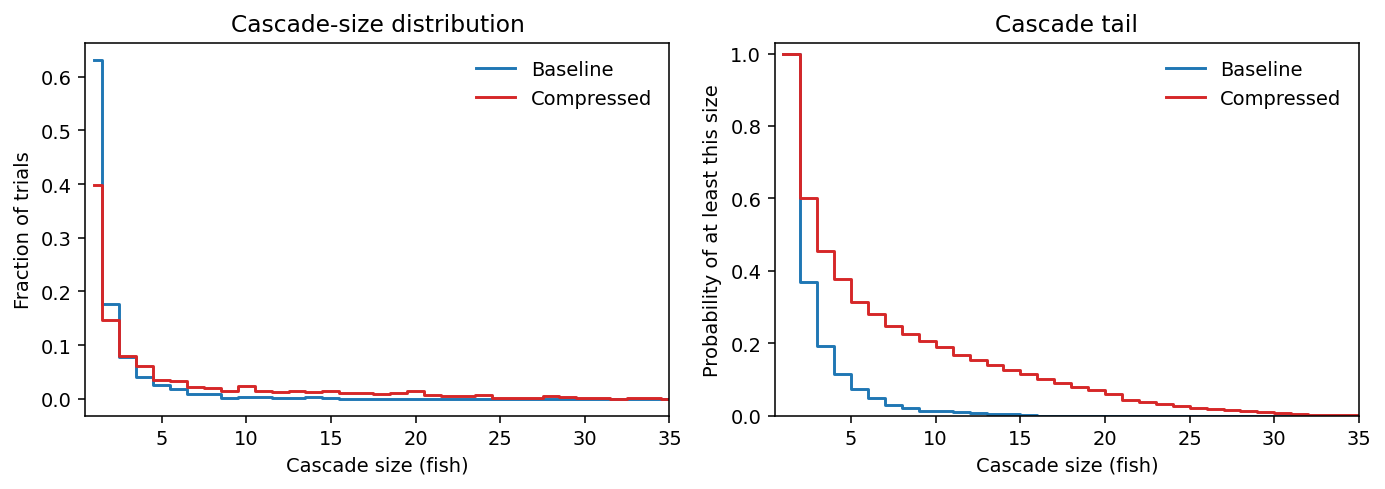

In [13]:
sizes = np.arange(1, n_fish + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for condition_id, label, color in zip(range(len(spatial_scales)), condition_labels, condition_colors):
    outcomes = cascade_sizes[:, condition_id]
    probability = np.bincount(outcomes, minlength=n_fish + 1)[1:] / n_runs
    tail_probability = (outcomes[:, None] >= sizes).mean(axis=0)
    axes[0].step(sizes, probability, where="mid", label=label, color=color)
    axes[1].step(sizes, tail_probability, where="post", label=label, color=color)
for ax in axes:
    ax.set(xlabel="Cascade size (fish)", xlim=(0.5, cascade_sizes.max() + 1))
    ax.legend(frameon=False)
axes[0].set(title="Cascade-size distribution", ylabel="Fraction of trials")
axes[1].set(title="Cascade tail", ylabel="Probability of at least this size", ylim=(0, 1.03))
fig.tight_layout()
fig.savefig(output_dir / "compression_cascades.png", dpi=180)
plt.show()


In [14]:
np.savez(
    output_dir / "compression_results.npz", cascade_sizes=cascade_sizes, run_ids=run_ids,
    spatial_scales=spatial_scales, mean_threshold=mean_threshold, network_seed=network_seed,
)


Sosna et al. (2019) reported closer spacing, fewer visible neighbours, and
larger cascades after the first alarm-cue exposure (main Figs. 1 and 2).
This experiment tests that qualitative mechanism with fixed responsiveness.

The baseline threshold was calibrated to the approximate frequency of secondary
escapes in SI Fig. S5A. No compressed-school outcomes were used for calibration.
Matching the direction of change is evidence for the mechanism within this
synthetic model, not a quantitative reproduction of the empirical distribution.
The visual geometry is approximate and the original logarithm convention remains
unverified.


## Result for this school

Across the paired trials, mean cascade size increased from **1.897 to 5.226 fish**.
The paired increase was **3.329 fish**, with a bootstrap 95% interval of
**2.975 to 3.702**. The fraction recruiting at least one secondary fish increased
from **36.8% to 60.2%**, a change of **23.4 percentage points** with a 95% interval
of **20.7 to 26.1 percentage points**.

Contraction reduced median nearest-neighbour distance from **6.00 to 4.20 cm**
and mean visible-neighbour count from **23.98 to 19.90**, while increasing mean
non-zero weight from **0.01150 to 0.02133**. Compressed cascades were larger in
**49.0%** of pairs and smaller in **1.5%**; the remaining pairs tied.

This reproduces the qualitative increase in propagation through spatial change
at fixed responsiveness. Its magnitude is larger than the roughly **0.954-fish**
increase reported for first exposure in Sosna et al.'s main Fig. 2B. The school
and visual geometry here are synthetic, and the baseline calibration used only
one recruitment statistic. This is therefore a mechanism demonstration on one
configuration, not a quantitative fit to their before/after distributions.
